In [1]:
import multiprocessing as mp
mp.set_start_method("spawn", force=True)

In [2]:
import os
os.environ["OMP_NUM_THREADS"]="1"
os.environ["MKL_NUM_THREADS"]="1"
os.environ["OPENBLAS_NUM_THREADS"]="1"
os.environ["NUMEXPR_NUM_THREADS"]="1"


In [3]:
### automatically refresh the buffer
%load_ext autoreload
%autoreload 2

### solve the auto-complete issue

%config Completer.use_jedi = False
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)

### lvl 2 setups (systerm)
import os
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap,LinearSegmentedColormap,BoundaryNorm
import matplotlib.dates as mdates
import geopandas as gpd
from shapely.geometry import Point
from datetime import datetime

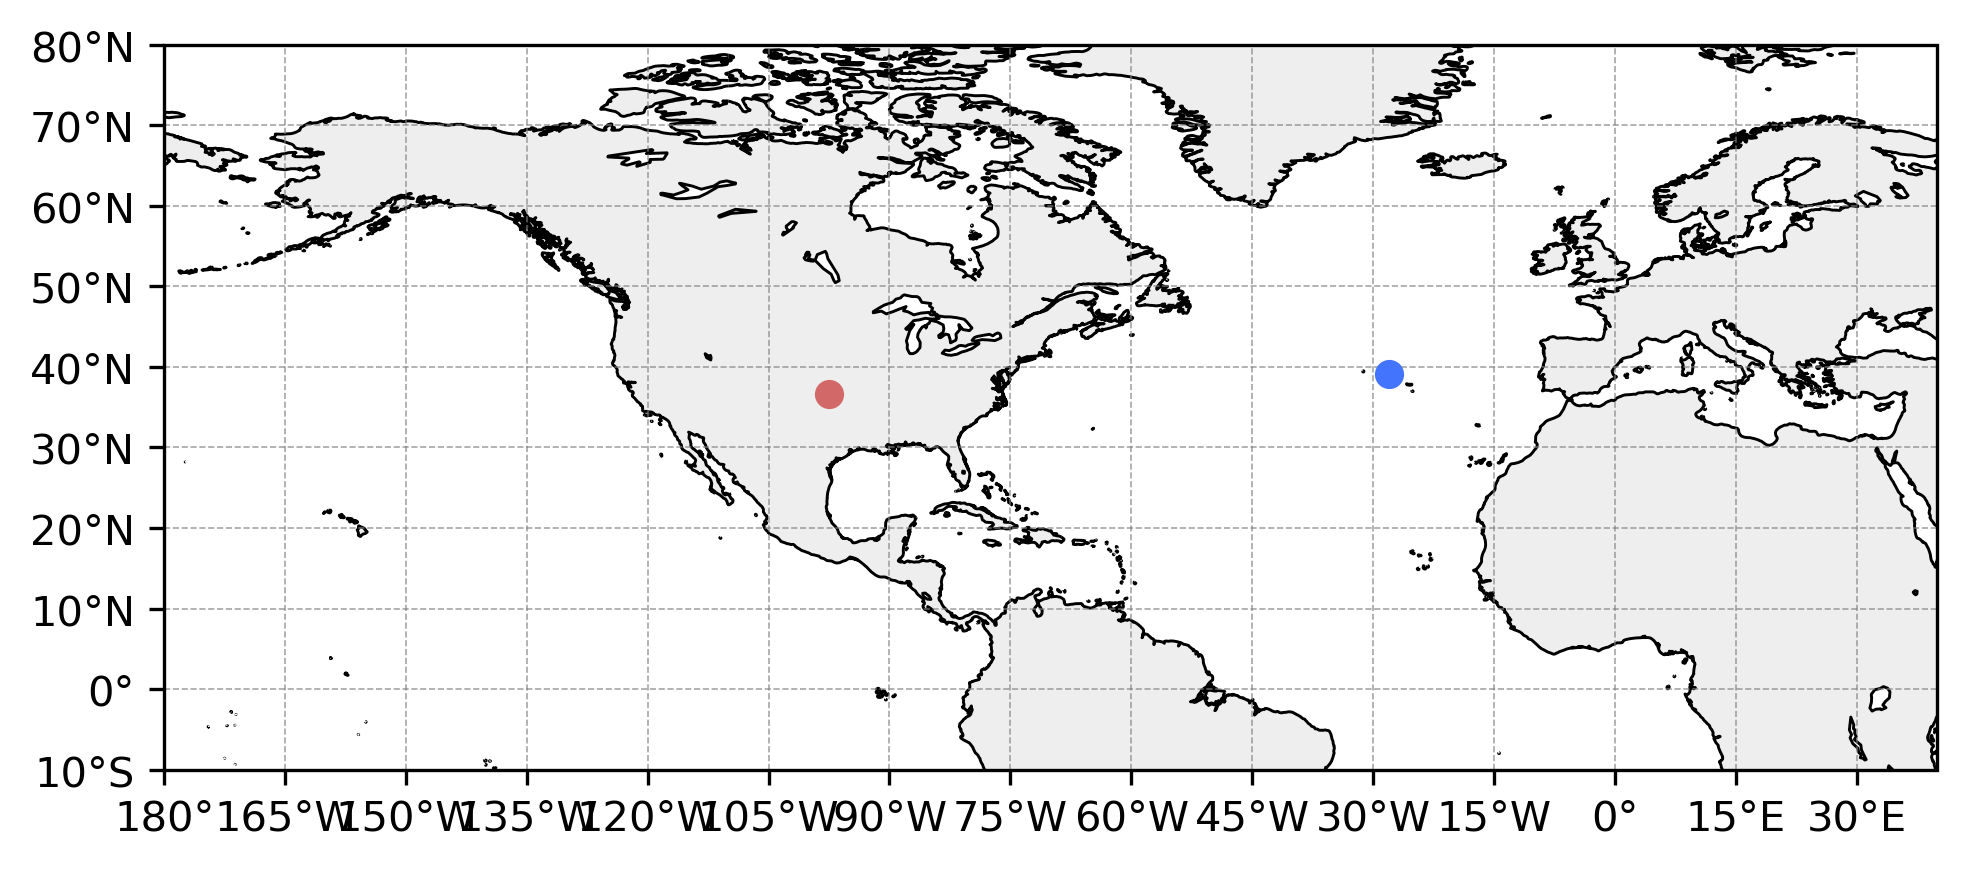

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy import geodesic

# === ENA 站点坐标 ===
lat_ena, lon_ena = 39.0916, -28.0257
lat_sgp, lon_sgp = 36.607322, -97.487643
# === 画布与投影 ===
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(8, 3), dpi=300)
ax = plt.axes(projection=proj)

# === 底图 ===
ax.add_feature(cfeature.OCEAN.with_scale('50m'), facecolor='#FFFFFF')
ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='#eeeeee')
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.7)

ax.add_feature(cfeature.LAKES.with_scale('110m'), facecolor='#FFFFFF', edgecolor='k', linewidth=0.7)
xticks = np.arange(-180, 181, 15)
yticks = np.arange(-90,  91, 10)

ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.set_yticks(yticks, crs=ccrs.PlateCarree())

from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
ax.xaxis.set_major_formatter(LongitudeFormatter(number_format='.0f'))
ax.yaxis.set_major_formatter(LatitudeFormatter(number_format='.0f'))

# === 网格线（关键：指定 xlocs / ylocs）===
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=False,
    linewidth=0.4,
    color='gray',
    linestyle='--',
    alpha=0.7,
    xlocs=xticks,
    ylocs=yticks,
)# === 绘制 ENA 站点 ===
# 小圆点（实心）
ax.plot(lon_sgp, lat_sgp, 'o', color='#d26868', markersize=6, transform=ccrs.PlateCarree(), zorder=5)
ax.plot(lon_ena, lat_ena, 'o', color='#4374fe', markersize=6, transform=ccrs.PlateCarree(), zorder=5)

# === 聚焦 ENA 区域 ===
ax.set_extent([-180, 40, -10, 80], crs=ccrs.PlateCarree())

# === 标题 ===

plt.tight_layout()
plt.show()


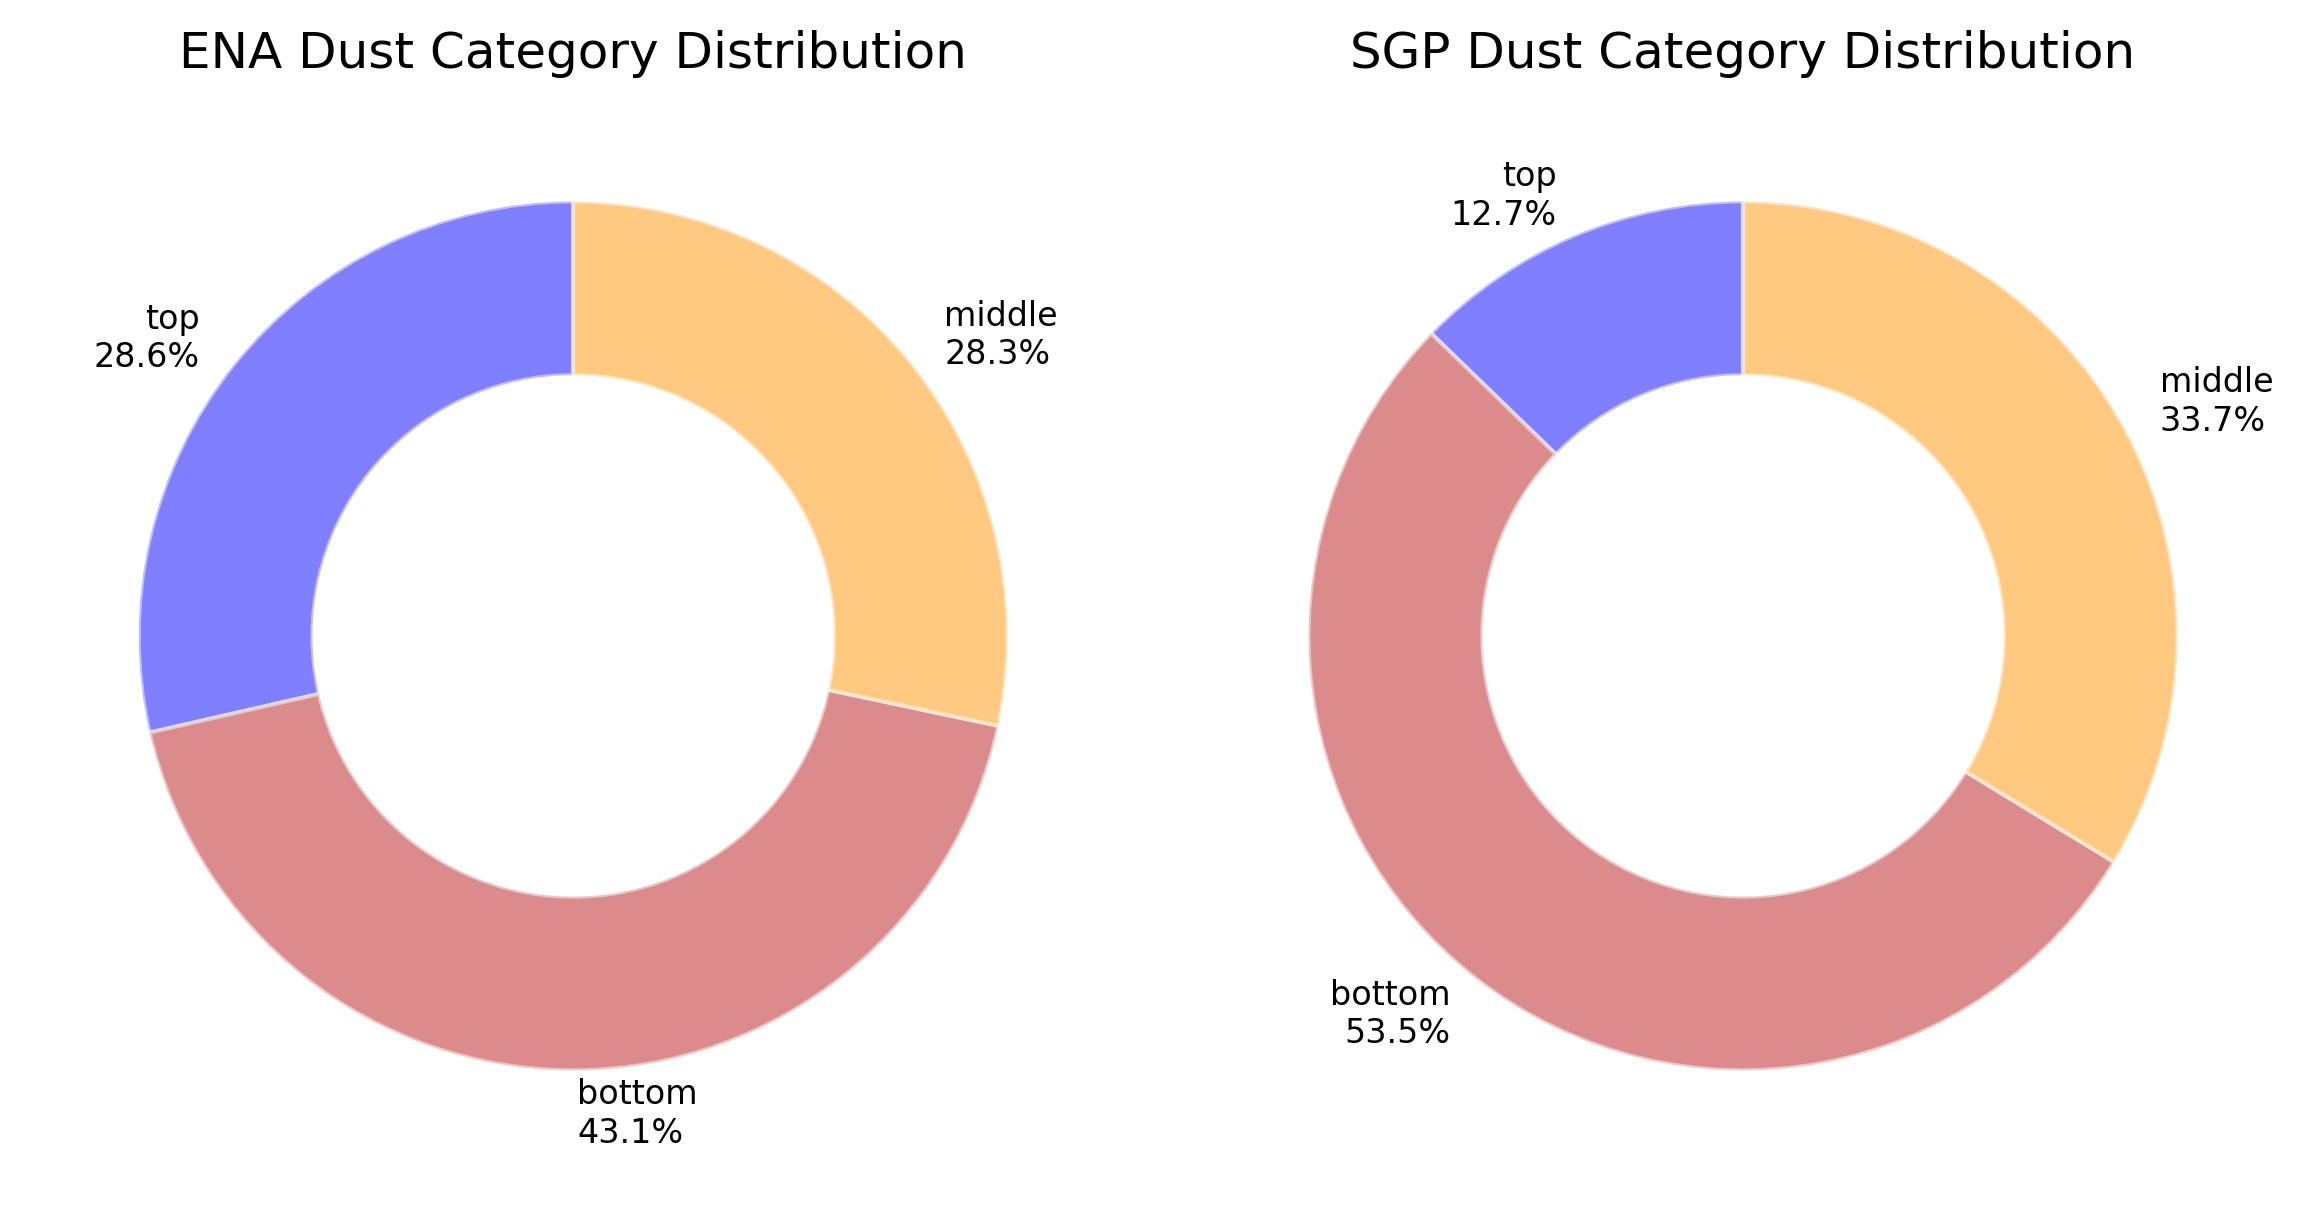

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# ==== Colors ====
cat_colors = {"top": "b", "bottom": "#ba181b", "middle": "#ff9505"}
colors = [cat_colors["top"], cat_colors["bottom"], cat_colors["middle"]]
alpha = 0.5

# ==== Data ====
labels = ["top", "bottom", "middle"]
ENA = np.array([7497, 11311, 7430], dtype=float)
SGP = np.array([735, 3088, 1944], dtype=float)

# ==== Percentage ====
ENA_pct = ENA / ENA.sum() * 100
SGP_pct = SGP / SGP.sum() * 100

# ==== Donut pie plotting function ====
def draw_donut(ax, pct, title):
    wedges, texts = ax.pie(
        pct,
        labels=[f"{lab}\n{p:.1f}%" for lab, p in zip(labels, pct)],
        colors=colors,
        startangle=90,
        textprops={'fontsize': 8},
        wedgeprops=dict(width=0.4, edgecolor="white", alpha=alpha),
    )
    ax.set_title(title)

# ==== Plot ====
fig, axes = plt.subplots(1, 2, figsize=(8, 4), dpi=300)

draw_donut(axes[0], ENA_pct, "ENA Dust Category Distribution")
draw_donut(axes[1], SGP_pct, "SGP Dust Category Distribution")

plt.tight_layout()
# plt.savefig("figsave/cate_fraction_donuts.pdf", dpi=300, bbox_inches='tight')
plt.show()


In [6]:
import glob, re
import pandas as pd
import xarray as xr

files = sorted(glob.glob("/data/shared_data/satellite_data/MODIS/monthly/netcdf_subset/MOD08_M3_*.nc"))

def add_time(ds, filename=None):
    # 从文件名解析 YYYYMM
    m = re.search(r"MOD08_M3_(\d{6})\.nc$", filename)
    yyyymm = m.group(1)
    t = pd.to_datetime(yyyymm + "01", format="%Y%m%d")
    return ds.expand_dims(time=[t])

# open_mfdataset 的 preprocess 只接收 ds，所以用 lambda 把 filename 传进去
datasets = []
for f in files:
    ds = xr.open_dataset(f)
    ds = add_time(ds, f)
    datasets.append(ds)

ds = xr.concat(datasets, dim="time").sortby("time")
print(ds.dims)


FrozenMappingWarningOnValuesAccess({'time': 155, 'lat': 180, 'lon': 360, 'Effective_Optical_Depth_Average_Ocean_Micron_Levels': 7, 'Pressure_Level_mod08': 20, 'XDim_mod08': 360, 'YDim_mod08': 180, 'Effective_Optical_Depth_Average_Ocean_Micron_Levels_mod08': 7})


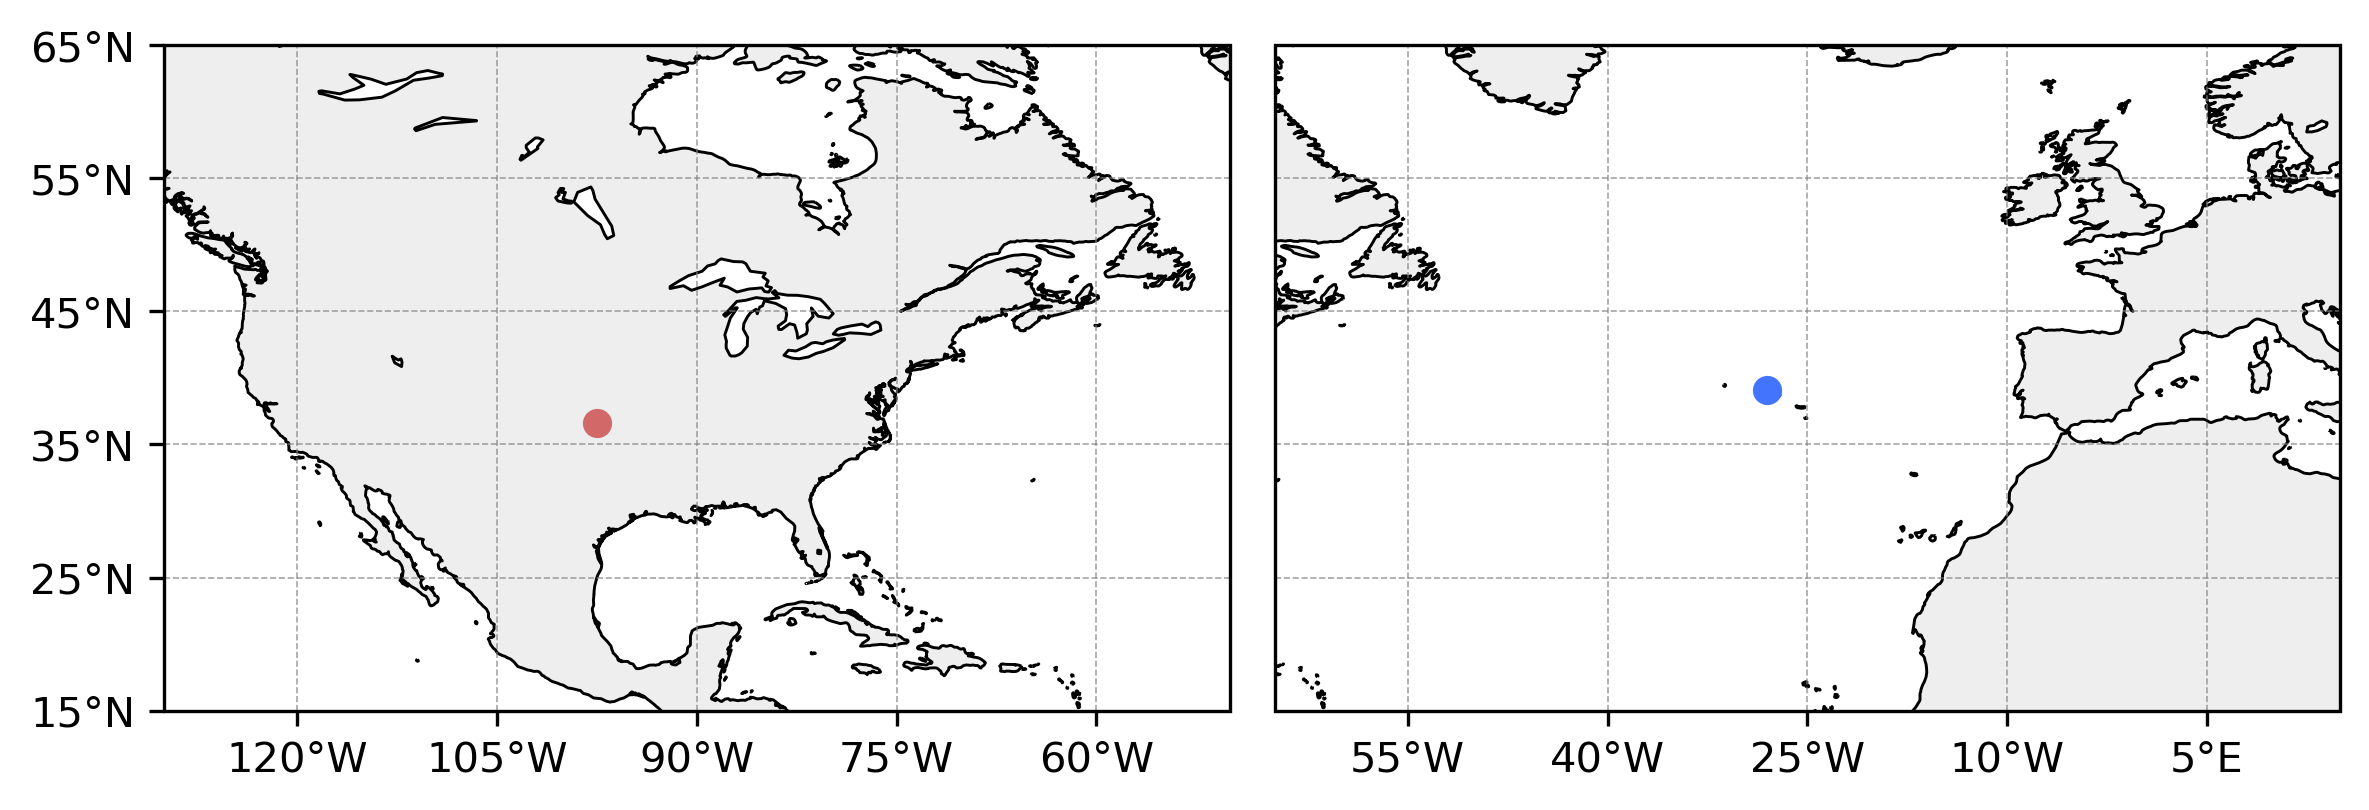

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# === ENA / SGP 坐标 ===
lat_ena, lon_ena = 39.0916, -28.0257
lat_sgp, lon_sgp = 36.607322, -97.487643

# === 投影 & 画布（共享 y 轴）===
proj = ccrs.PlateCarree()
fig, axes = plt.subplots(1, 2, figsize=(8, 3), dpi=300, subplot_kw={"projection": proj}, sharey=True)

# === 范围（你给的）===
extents = [[-130, -50, 15, 65], [-65, 15, 15, 65]]

# === 关键：你要的是 W/E 显示，但数值必须用“正东负西” ===
# 左图: 120W,105W,90W,75W,60W -> [-120,-105,-90,-75,-60]
# 右图: 55W,40W,25W,10W,5E    -> [-55,-40,-25,-10,  5]
xticks_list = [[-120, -105, -90, -75, -60], [-55, -40, -25, -10, 5]]

# === y 轴刻度（统一）===
yticks = np.arange(15, 66, 10)

for i, (ax, ext, xticks) in enumerate(zip(axes, extents, xticks_list)):

    # --- 底图 ---
    ax.add_feature(cfeature.OCEAN.with_scale("50m"), facecolor="#FFFFFF")
    ax.add_feature(cfeature.LAND.with_scale("50m"), facecolor="#eeeeee")
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.7)
    ax.add_feature(cfeature.LAKES.with_scale("110m"), facecolor="#FFFFFF", edgecolor="k", linewidth=0.7)

    # --- 范围 ---
    ax.set_extent(ext, crs=proj)

    # --- 刻度：完全按你给的（但用正东负西） ---
    ax.set_xticks(xticks, crs=proj)
    ax.xaxis.set_major_formatter(LongitudeFormatter(number_format=".0f"))

    if i == 0:
        ax.set_yticks(yticks, crs=proj)
        ax.yaxis.set_major_formatter(LatitudeFormatter(number_format=".0f"))
    else:
        ax.tick_params(labelleft=False)

    # --- 网格线（与刻度一致） ---
    ax.gridlines(crs=proj, draw_labels=False, linewidth=0.4,
                 color="gray", linestyle="--", alpha=0.7,
                 xlocs=xticks, ylocs=yticks)

    # --- 站点 ---
    ax.plot(lon_sgp, lat_sgp, "o", color="#d26868", ms=6, transform=proj, zorder=5)
    ax.plot(lon_ena, lat_ena, "o", color="#4374fe", ms=6, transform=proj, zorder=5)

plt.tight_layout()
plt.savefig("figsave/study_area.pdf", dpi=300, bbox_inches='tight')
plt.show()



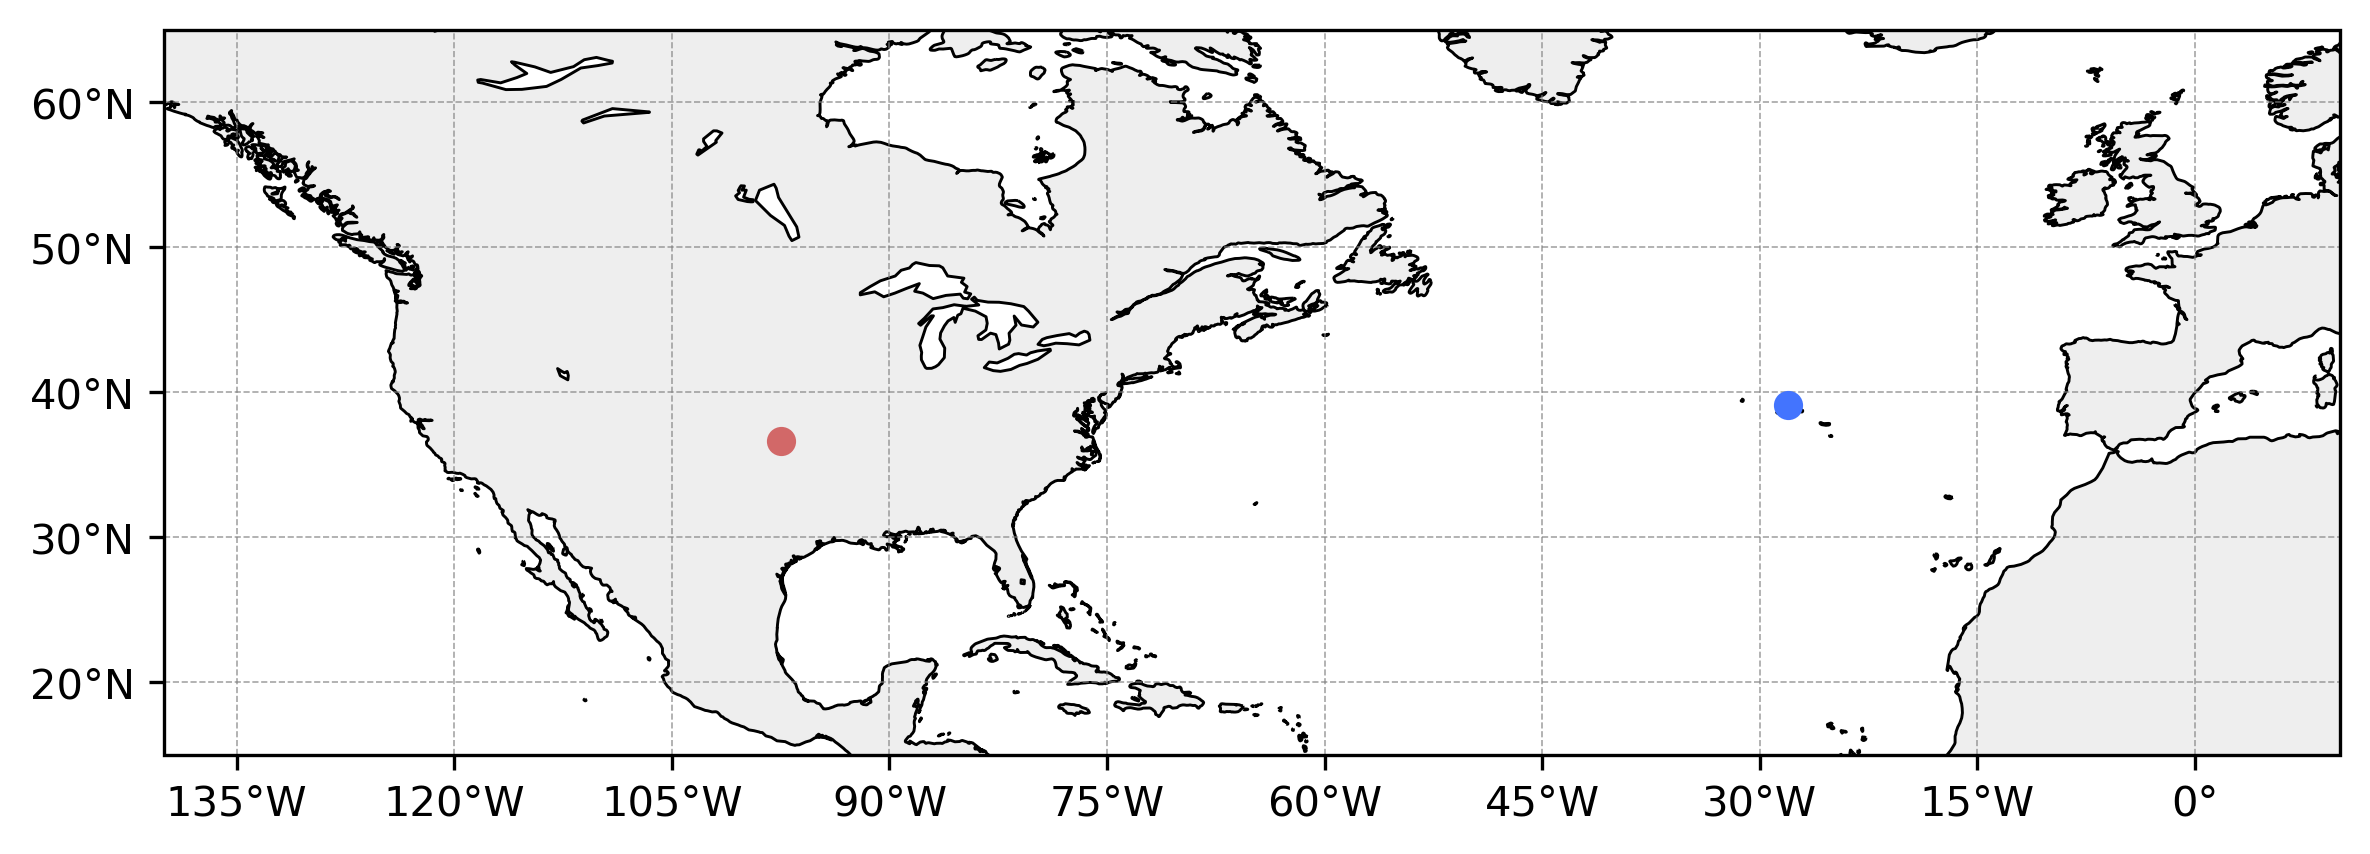

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy import geodesic

# === ENA 站点坐标 ===
lat_ena, lon_ena = 39.0916, -28.0257
lat_sgp, lon_sgp = 36.607322, -97.487643
# === 画布与投影 ===
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(8, 3), dpi=300)
ax = plt.axes(projection=proj)

# === 底图 ===
ax.add_feature(cfeature.OCEAN.with_scale('50m'), facecolor='#FFFFFF')
ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='#eeeeee')
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.7)

ax.add_feature(cfeature.LAKES.with_scale('110m'), facecolor='#FFFFFF', edgecolor='k', linewidth=0.7)
xticks = np.arange(-180, 181, 15)
yticks = np.arange(-90,  91, 10)

ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.set_yticks(yticks, crs=ccrs.PlateCarree())

from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
ax.xaxis.set_major_formatter(LongitudeFormatter(number_format='.0f'))
ax.yaxis.set_major_formatter(LatitudeFormatter(number_format='.0f'))

# === 网格线（关键：指定 xlocs / ylocs）===
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=False,
    linewidth=0.4,
    color='gray',
    linestyle='--',
    alpha=0.7,
    xlocs=xticks,
    ylocs=yticks,
)# === 绘制 ENA 站点 ===
# 小圆点（实心）
ax.plot(lon_sgp, lat_sgp, 'o', color='#d26868', markersize=6, transform=ccrs.PlateCarree(), zorder=5)
ax.plot(lon_ena, lat_ena, 'o', color='#4374fe', markersize=6, transform=ccrs.PlateCarree(), zorder=5)

# === 聚焦 ENA 区域 ===
ax.set_extent([-140, 10, 15, 65], crs=ccrs.PlateCarree())

# === 标题 ===
# plt.savefig("figsave/study_area.pdf", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

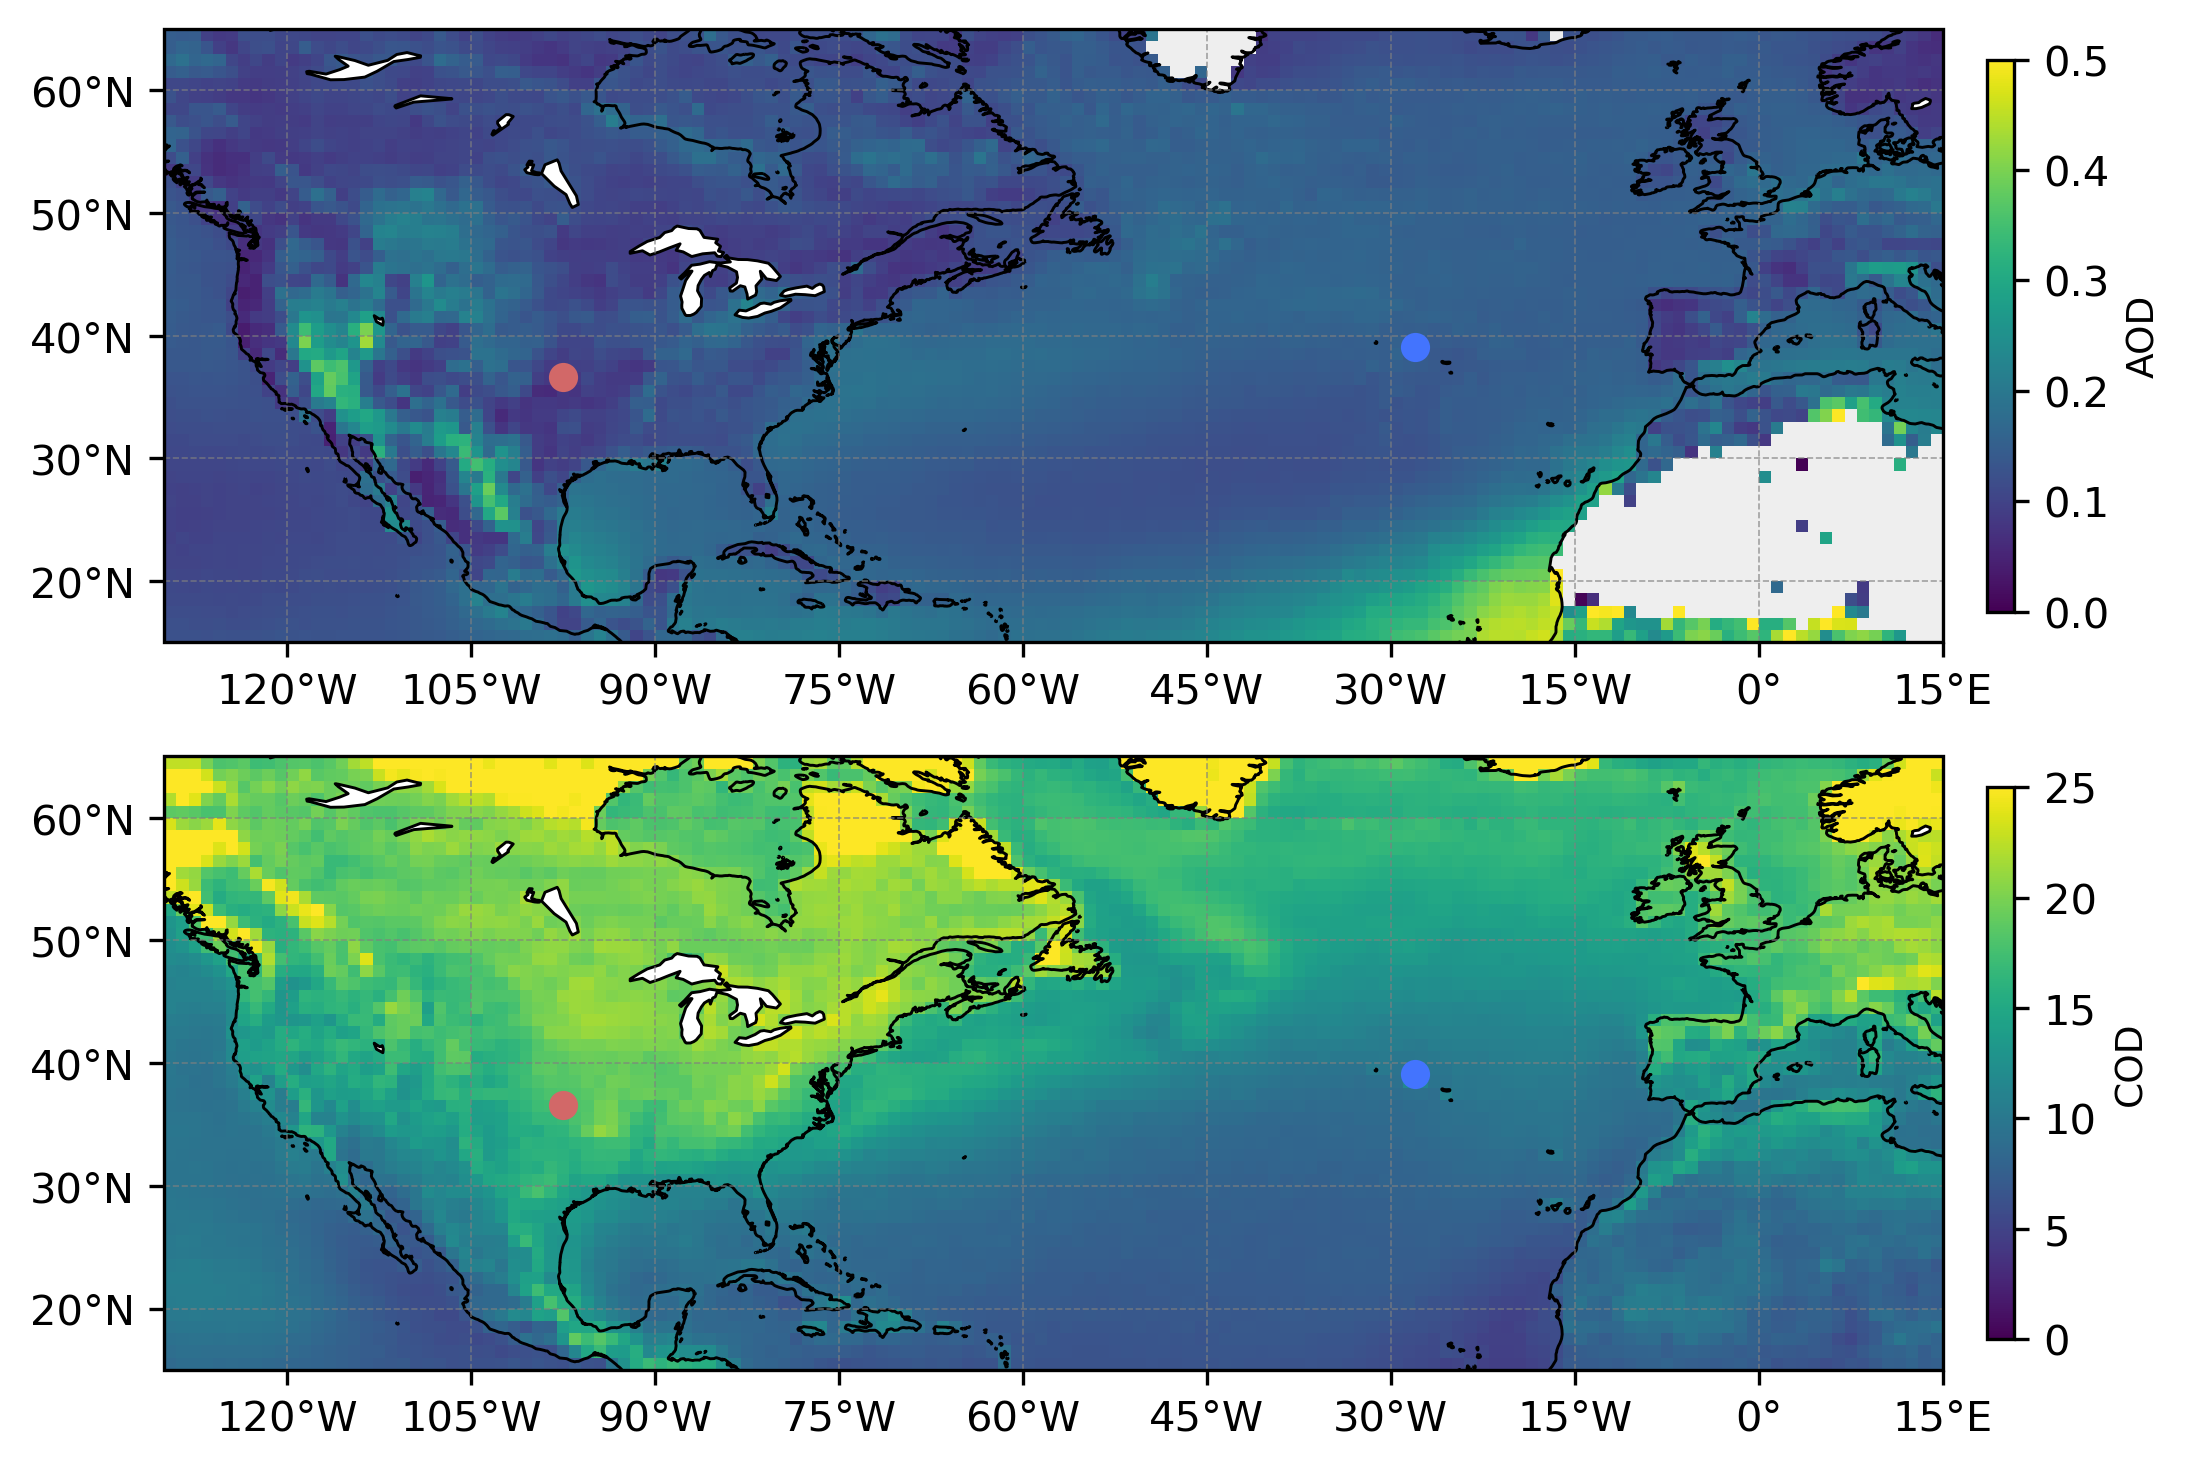

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
ds_sel = ds.sel(time=slice("2000-01-01", "2012-12-01"))
lon = ds["lon"].values
lat = ds["lat"].values
Lon, Lat = np.meshgrid(lon, lat)
# AOD climatology
aod_clim = ds_sel["Optical_Depth_Land_And_Ocean_Mean_Mean"].mean("time", skipna=True)

# COD climatology (MODIS 叫 Thickness，但就是 COD)
cod_clim = ds_sel["Cloud_Optical_Thickness_Liquid_Mean_Mean"].mean("time", skipna=True)

# === 站点 ===
lat_ena, lon_ena = 39.0916, -28.0257
lat_sgp, lon_sgp = 36.607322, -97.487643

# === 画布 ===
proj = ccrs.PlateCarree()
fig, axes = plt.subplots(
    nrows=2, ncols=1,
    figsize=(8, 5),
    dpi=300,
    subplot_kw={"projection": proj}
)

fields = [aod_clim, cod_clim]
vmins = [0.0, 0.0]
vmaxs = [0.5, 25.0]
titles = [
    "MODIS AOD Climatology (2003–2012)",
    "MODIS COD Climatology (2003–2012)"
]
cbar_labels = ["AOD", "COD"]

for i, (ax, field, title, cbar_label) in enumerate(zip(axes, fields, titles, cbar_labels)):

    ax.add_feature(cfeature.OCEAN.with_scale('50m'), facecolor='#FFFFFF')
    ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='#eeeeee')
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.7)
    ax.add_feature(cfeature.LAKES.with_scale('110m'),
                   facecolor='#FFFFFF', edgecolor='k', linewidth=0.7)

    xticks = np.arange(-180, 181, 15)
    yticks = np.arange(-90,  91, 10)

    ax.set_xticks(xticks, crs=proj)
    ax.set_yticks(yticks, crs=proj)

    ax.xaxis.set_major_formatter(LongitudeFormatter(number_format='.0f'))
    ax.yaxis.set_major_formatter(LatitudeFormatter(number_format='.0f'))

    ax.gridlines(
        crs=proj, draw_labels=False,
        linewidth=0.4, linestyle='--', color='gray',
        xlocs=xticks, ylocs=yticks, alpha=0.7
    )

    pcm = ax.pcolormesh(
        Lon, Lat, field.values,vmin=vmins[i], vmax=vmaxs[i],
        shading="auto", transform=proj
    )

    # === 站点 ===
    ax.plot(lon_sgp, lat_sgp, 'o', color='#d26868',
            markersize=6, transform=proj, zorder=5)
    ax.plot(lon_ena, lat_ena, 'o', color='#4374fe',
            markersize=6, transform=proj, zorder=5)

    ax.set_extent([-130, 15, 15, 65], crs=proj)
    # ax.set_title(title, fontsize=10)

    cbar = plt.colorbar(pcm, ax=ax, pad=0.02, shrink=0.9)
    cbar.set_label(cbar_label, fontsize=9)

plt.tight_layout()
plt.show()


## 3 cates events occurance

In [10]:
df_top = pd.read_csv('/data/ggong/ARM_monthly/ENA/df_top.csv')
df_middle = pd.read_csv('/data/ggong/ARM_monthly/ENA/df_middle.csv')
df_bottom = pd.read_csv('/data/ggong/ARM_monthly/ENA/df_bottom.csv')

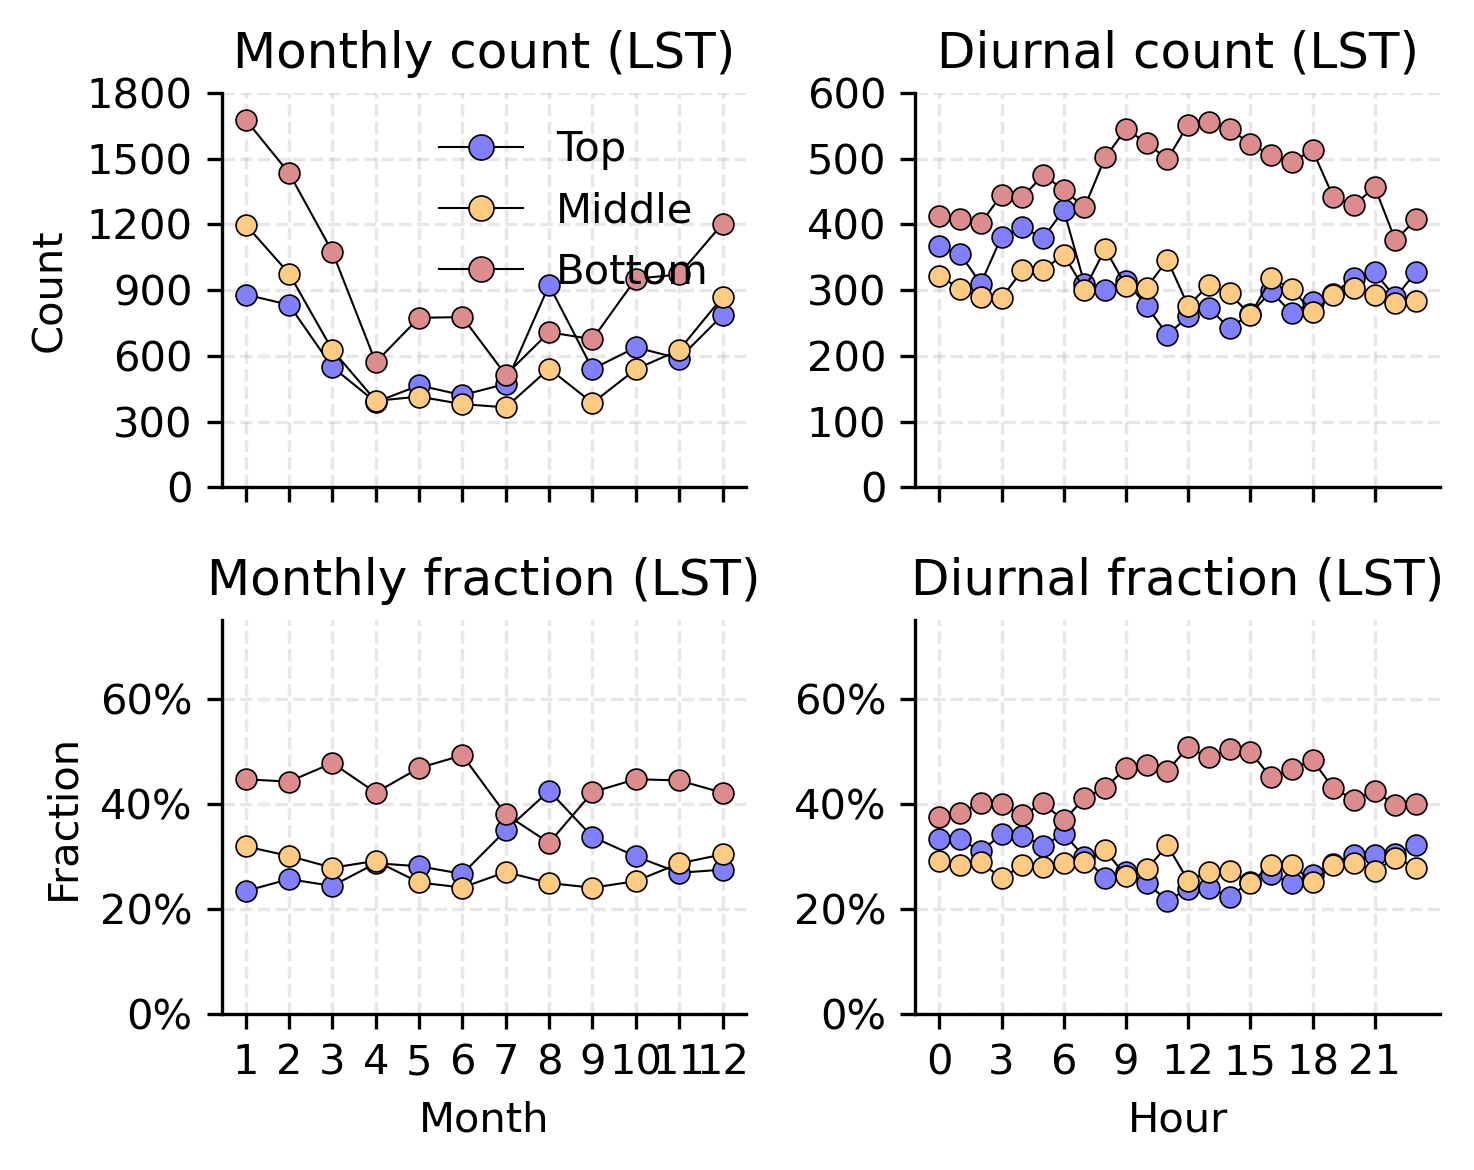

In [11]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, PercentFormatter

cat_colors={"top":"#8080ff","middle":"#ffca82","bottom":"#dd8c8d"}; cats={"top":df_top,"middle":df_middle,"bottom":df_bottom}

for k in cats:
    t=pd.to_datetime(dict(year=cats[k].year,month=cats[k].month,day=cats[k].day))+pd.to_timedelta(cats[k].hour,unit="h")-pd.to_timedelta(1,unit="h")
    cats[k]["month_lst"],cats[k]["hour_lst"]=t.dt.month,t.dt.hour

months,hours=np.arange(1,13),np.arange(24)
m_cnt={k:cats[k].month_lst.value_counts().reindex(months,fill_value=0).values for k in cats}
h_cnt={k:cats[k].hour_lst.value_counts().reindex(hours ,fill_value=0).values for k in cats}
m_tot,h_tot=sum(m_cnt.values()),sum(h_cnt.values())
m_frac={k:m_cnt[k]/np.where(m_tot==0,np.nan,m_tot) for k in cats}
h_frac={k:h_cnt[k]/np.where(h_tot==0,np.nan,h_tot) for k in cats}

fig,ax=plt.subplots(2,2,figsize=(5,4),dpi=300,sharex='col')  # ✅ no sharey
from matplotlib.lines import Line2D
legend_handles = [Line2D([0],[0],marker='o',lw=0.5,color='k',mfc=cat_colors[k],mec='k',mew=0.4,ms=6,label=k.capitalize())
                  for k in ["top","middle","bottom"]]

def draw(a,x,d,ylabel=None,title=None):
    for k in ["top","middle","bottom"]:
        a.plot(x,d[k],color='k',lw=0.5)
        a.plot(x,d[k],'o',mfc=cat_colors[k],mec='k',mew=0.4,ms=5)
    a.grid(alpha=0.3,ls='--'); a.spines[['top','right']].set_visible(False)
    if ylabel: a.set_ylabel(ylabel)
    if title: a.set_title(title)

draw(ax[0,0],months,m_cnt,"Count","Monthly count (LST)");  ax[0,0].set_xticks(months);           ax[0,0].set_ylim(0,1800); ax[0,0].yaxis.set_major_locator(MultipleLocator(300))
draw(ax[0,1],hours ,h_cnt,None ,"Diurnal count (LST)");    ax[0,1].set_xticks(np.arange(0,24,3)); ax[0,1].set_ylim(0,600);  ax[0,1].yaxis.set_major_locator(MultipleLocator(100))

draw(ax[1,0],months,m_frac,"Fraction","Monthly fraction (LST)"); ax[1,0].set_xticks(months);           ax[1,0].set_xlabel("Month"); ax[1,0].set_ylim(0.0,0.75); ax[1,0].yaxis.set_major_locator(MultipleLocator(0.2)); ax[1,0].yaxis.set_major_formatter(PercentFormatter(xmax=1,decimals=0))
draw(ax[1,1],hours ,h_frac,None ,"Diurnal fraction (LST)");       ax[1,1].set_xticks(np.arange(0,24,3)); ax[1,1].set_xlabel("Hour");  ax[1,1].set_ylim(0.0,0.75); ax[1,1].yaxis.set_major_locator(MultipleLocator(0.2)); ax[1,1].yaxis.set_major_formatter(PercentFormatter(xmax=1,decimals=0))
ax[0,0].legend(handles=legend_handles, frameon=False, loc="upper right")

plt.tight_layout(); plt.savefig("figsave/ENA_occur.pdf", dpi=300, bbox_inches='tight'); plt.show()


In [12]:
df_top = pd.read_csv('/data/ggong/ARM_monthly/SGP/df_top.csv')
df_middle = pd.read_csv('/data/ggong/ARM_monthly/SGP/df_middle.csv')
df_bottom = pd.read_csv('/data/ggong/ARM_monthly/SGP/df_bottom.csv')

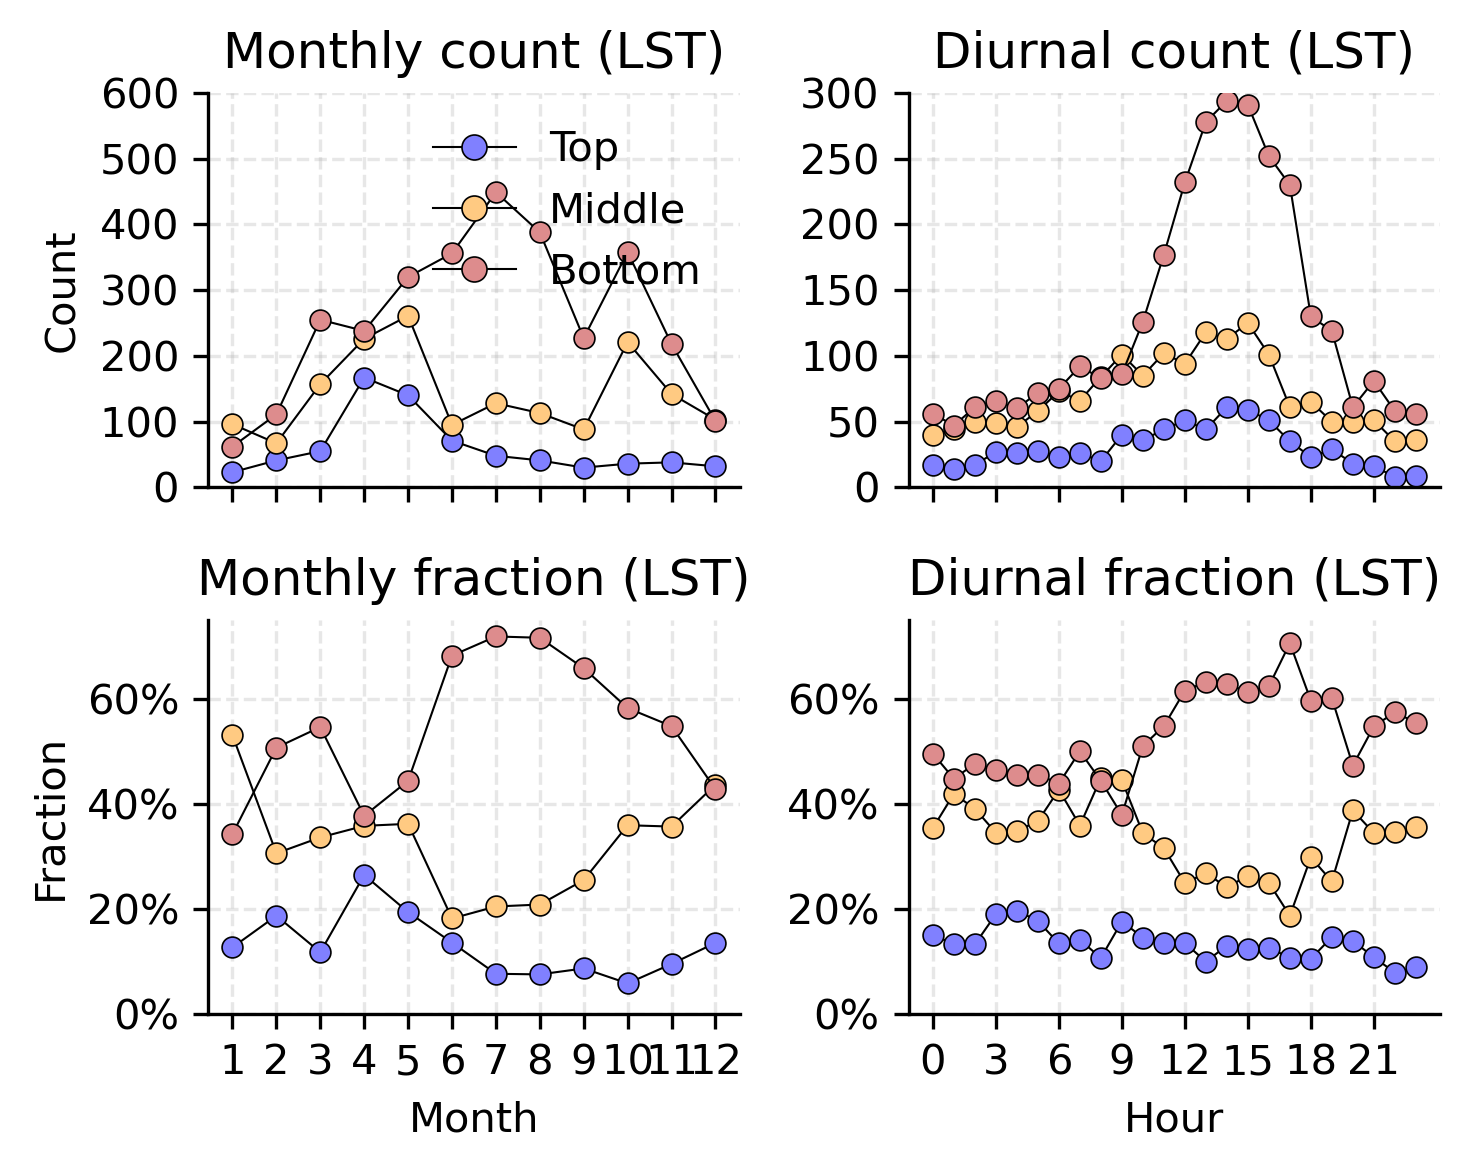

In [13]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, PercentFormatter

cat_colors={"top":"#8080ff","middle":"#ffca82","bottom":"#dd8c8d"}; cats={"top":df_top,"middle":df_middle,"bottom":df_bottom}

for k in cats:
    t=pd.to_datetime(dict(year=cats[k].year,month=cats[k].month,day=cats[k].day))+pd.to_timedelta(cats[k].hour,unit="h")-pd.to_timedelta(6,unit="h")
    cats[k]["month_lst"],cats[k]["hour_lst"]=t.dt.month,t.dt.hour

months,hours=np.arange(1,13),np.arange(24)
m_cnt={k:cats[k].month_lst.value_counts().reindex(months,fill_value=0).values for k in cats}
h_cnt={k:cats[k].hour_lst.value_counts().reindex(hours ,fill_value=0).values for k in cats}
m_tot,h_tot=sum(m_cnt.values()),sum(h_cnt.values())
m_frac={k:m_cnt[k]/np.where(m_tot==0,np.nan,m_tot) for k in cats}
h_frac={k:h_cnt[k]/np.where(h_tot==0,np.nan,h_tot) for k in cats}

fig,ax=plt.subplots(2,2,figsize=(5,4),dpi=300,sharex='col')  # ✅ no sharey
from matplotlib.lines import Line2D
legend_handles = [Line2D([0],[0],marker='o',lw=0.5,color='k',mfc=cat_colors[k],mec='k',mew=0.4,ms=6,label=k.capitalize())
                  for k in ["top","middle","bottom"]]

def draw(a,x,d,ylabel=None,title=None):
    for k in ["top","middle","bottom"]:
        a.plot(x,d[k],color='k',lw=0.5)
        a.plot(x,d[k],'o',mfc=cat_colors[k],mec='k',mew=0.4,ms=5)
    a.grid(alpha=0.3,ls='--'); a.spines[['top','right']].set_visible(False)
    if ylabel: a.set_ylabel(ylabel)
    if title: a.set_title(title)

draw(ax[0,0],months,m_cnt,"Count","Monthly count (LST)");  ax[0,0].set_xticks(months);           ax[0,0].set_ylim(0,600); ax[0,0].yaxis.set_major_locator(MultipleLocator(100))
draw(ax[0,1],hours ,h_cnt,None ,"Diurnal count (LST)");    ax[0,1].set_xticks(np.arange(0,24,3)); ax[0,1].set_ylim(0,300);  ax[0,1].yaxis.set_major_locator(MultipleLocator(50))

draw(ax[1,0],months,m_frac,"Fraction","Monthly fraction (LST)"); ax[1,0].set_xticks(months);           ax[1,0].set_xlabel("Month"); ax[1,0].set_ylim(0.0,0.75); ax[1,0].yaxis.set_major_locator(MultipleLocator(0.2)); ax[1,0].yaxis.set_major_formatter(PercentFormatter(xmax=1,decimals=0))
draw(ax[1,1],hours ,h_frac,None ,"Diurnal fraction (LST)");       ax[1,1].set_xticks(np.arange(0,24,3)); ax[1,1].set_xlabel("Hour");  ax[1,1].set_ylim(0.0,0.75); ax[1,1].yaxis.set_major_locator(MultipleLocator(0.2)); ax[1,1].yaxis.set_major_formatter(PercentFormatter(xmax=1,decimals=0))
ax[0,0].legend(handles=legend_handles, frameon=False, loc="upper right")

plt.tight_layout(); plt.savefig("figsave/SGP_occur.pdf", dpi=300, bbox_inches='tight'); plt.show()


## monthly and diurnal chara of ENA and SGP

In [46]:
df_top = pd.read_csv('/home/ggong/ARM/csv/ENA_top.csv')
df_middle = pd.read_csv('/home/ggong/ARM/csv/ENA_middle.csv')
df_bottom = pd.read_csv('/home/ggong/ARM/csv/ENA_bottom.csv')

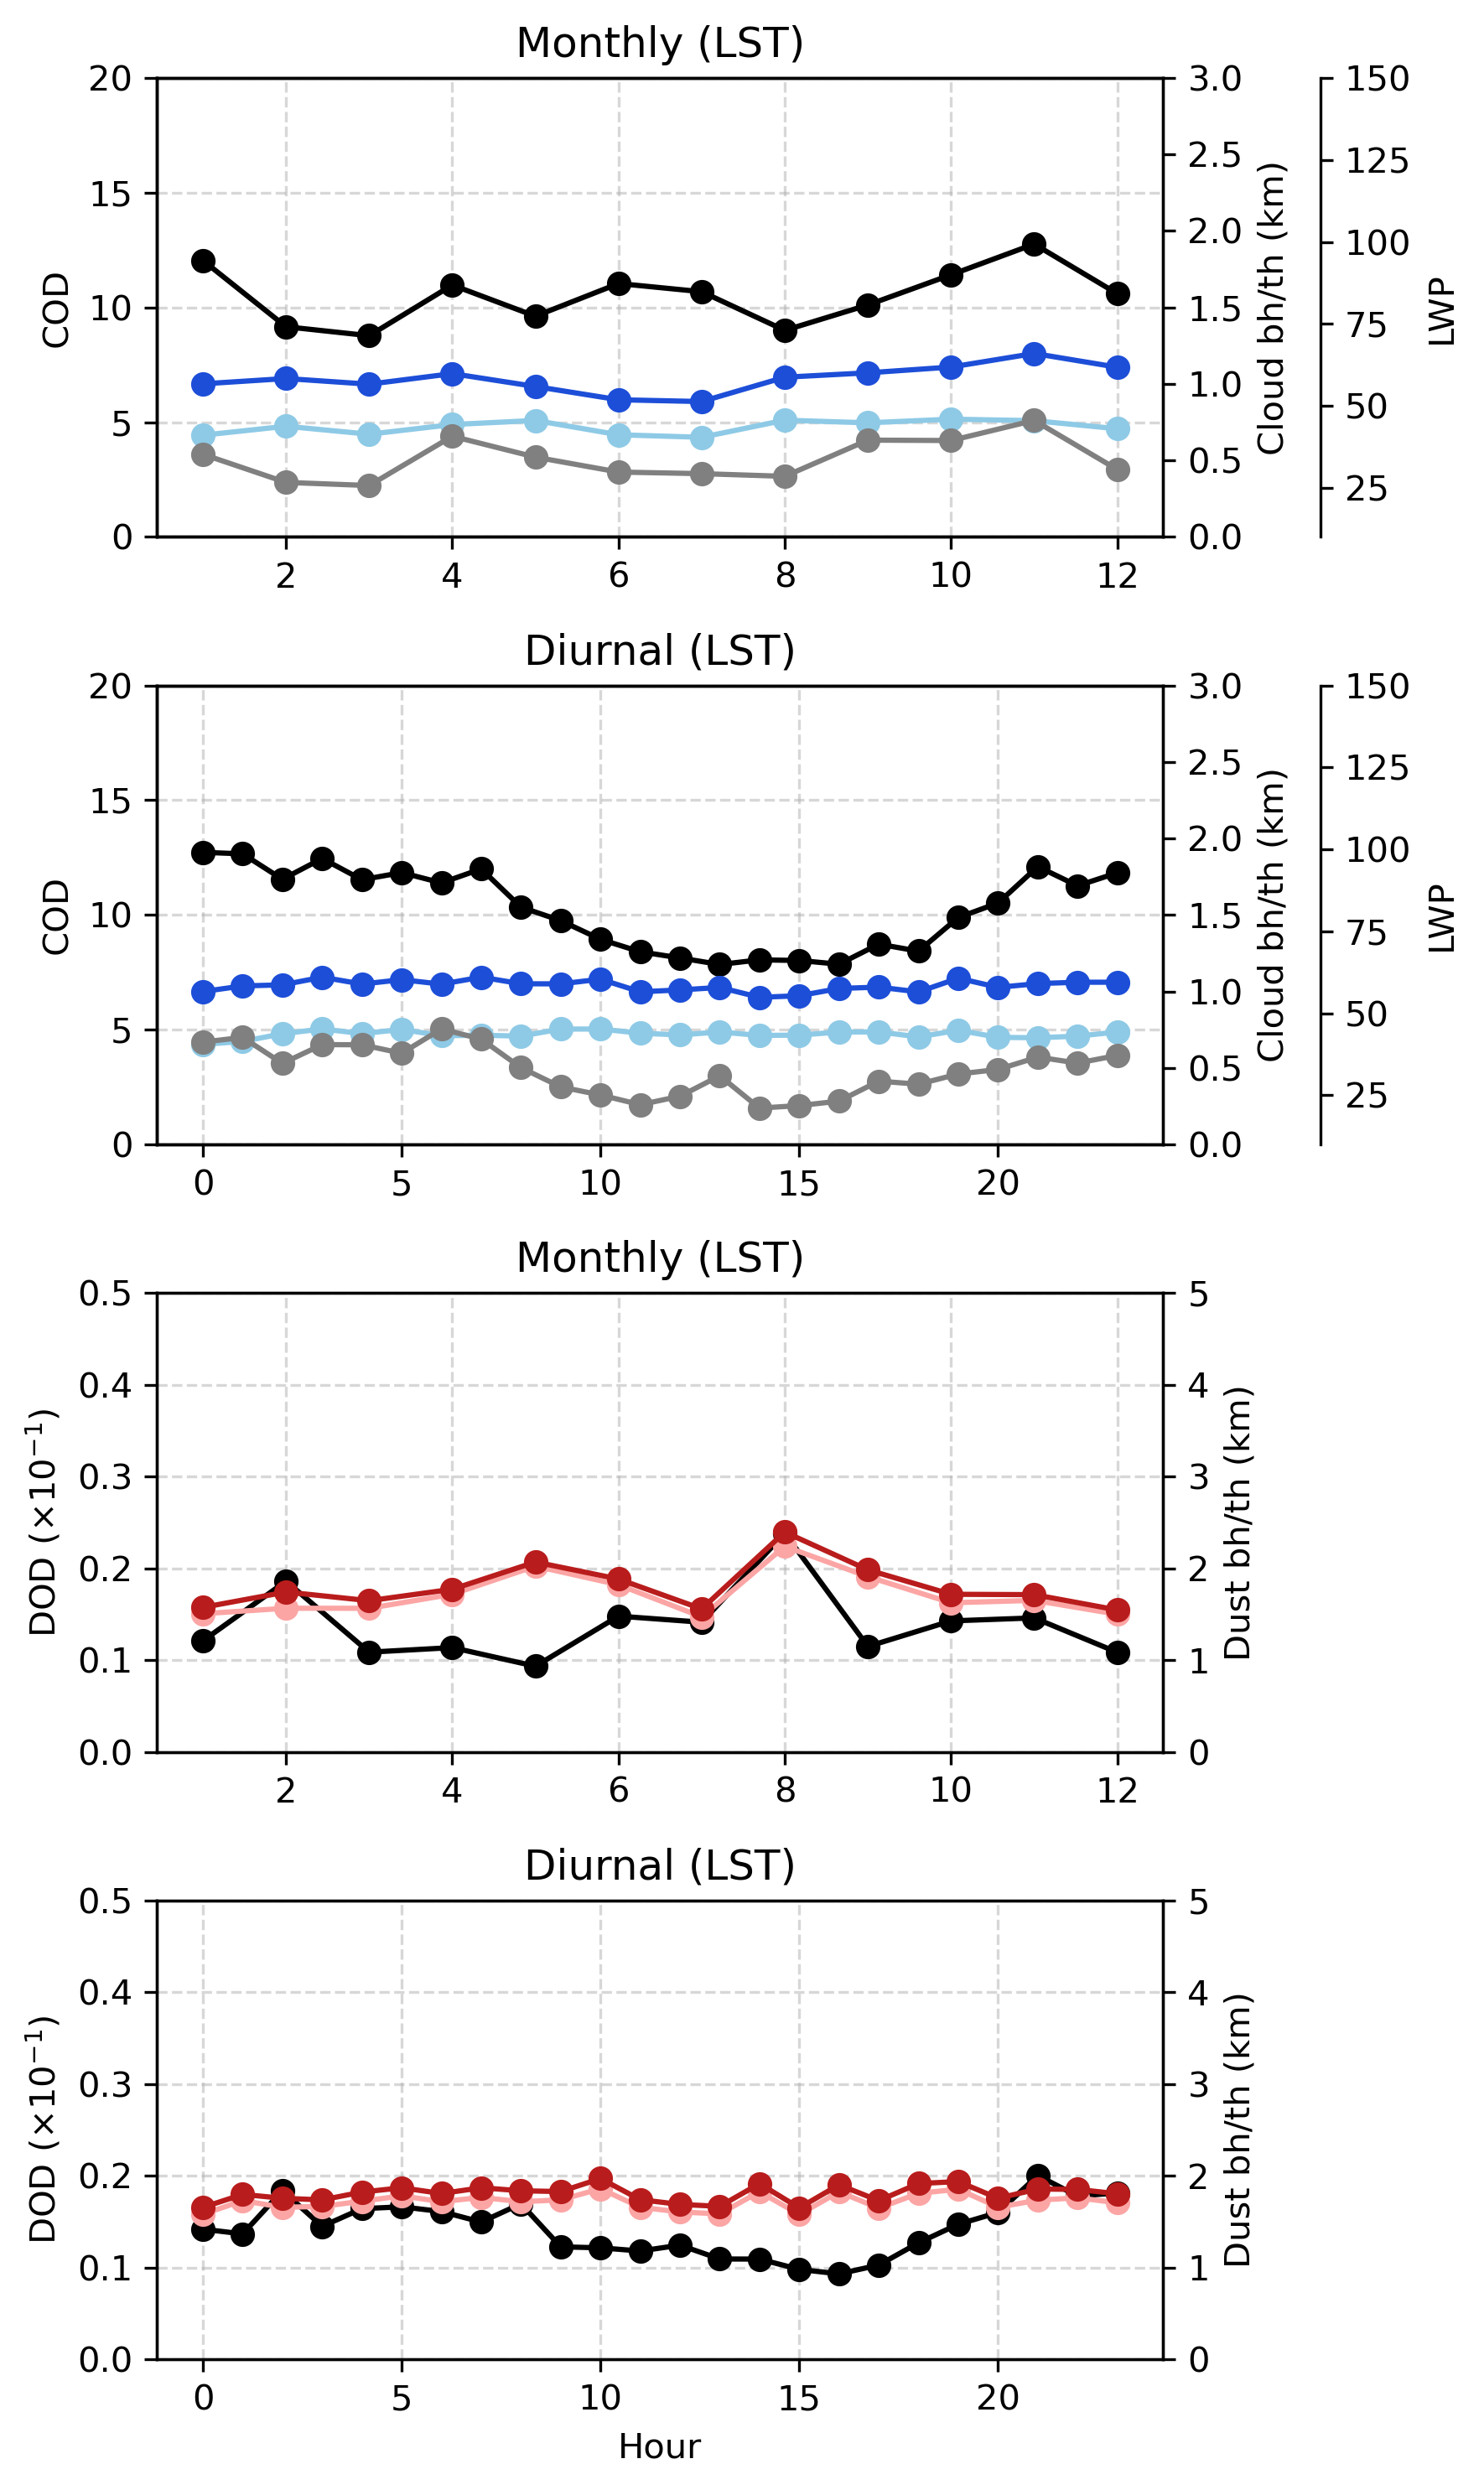

In [49]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# ===== UTC -> LST =====
df = df_top.copy()
t = pd.to_datetime(dict(year=df.year,month=df.month,day=df.day,hour=df.hour)) - pd.Timedelta(hours=1)
df["m"], df["h"] = t.dt.month, t.dt.hour

# ===== monthly / diurnal =====
mc = df.groupby("m")[["COD","cloud_bh","cloud_th","LWP"]].mean()
hc = df.groupby("h")[["COD","cloud_bh","cloud_th","LWP"]].mean()
md = df.groupby("m")[["DOD","dust_bh","dust_th"]].mean()
hd = df.groupby("h")[["DOD","dust_bh","dust_th"]].mean()

fig, ax = plt.subplots(4,1,figsize=(6,10),dpi=300)

# ===== ax1 monthly cloud =====
a=ax[0]; a.plot(mc.index,mc.COD/0.1,'ko-')
a.set(ylabel="COD",ylim=(0,20))
b=a.twinx(); b.plot(mc.index,mc.cloud_bh,'o-',c="#8ecae6"); b.plot(mc.index,mc.cloud_th,'o-',c="#1d4ed8")
b.set(ylabel="Cloud bh/th (km)",ylim=(0,3))
c=a.twinx(); c.spines.right.set_position(("outward",45))
c.plot(mc.index,mc.LWP,'o-',c="0.5"); c.set(ylabel="LWP",ylim=(10,150))
a.set_title("Monthly (LST)")

# ===== ax2 diurnal cloud =====
a=ax[1]; a.plot(hc.index,hc.COD/0.1,'ko-')
a.set(ylabel="COD",ylim=(0,20))
b=a.twinx(); b.plot(hc.index,hc.cloud_bh,'o-',c="#8ecae6"); b.plot(hc.index,hc.cloud_th,'o-',c="#1d4ed8")
b.set(ylabel="Cloud bh/th (km)",ylim=(0,3))
c=a.twinx(); c.spines.right.set_position(("outward",45))
c.plot(hc.index,hc.LWP,'o-',c="0.5"); c.set(ylabel="LWP",ylim=(10,150))
a.set_title("Diurnal (LST)")

# ===== ax3 monthly dust =====
a=ax[2]; a.plot(md.index,md.DOD/0.1,'ko-')
a.set(ylabel="DOD (×10$^{-1}$)",ylim=(0.00,0.5))
b=a.twinx(); b.plot(md.index,md.dust_bh,'o-',c="#fca5a5"); b.plot(md.index,md.dust_th,'o-',c="#b91c1c")
b.set(ylabel="Dust bh/th (km)",ylim=(0,5))
a.set_title("Monthly (LST)")

# ===== ax4 diurnal dust =====
a=ax[3]; a.plot(hd.index,hd.DOD/0.1,'ko-')
a.set(ylabel="DOD (×10$^{-1}$)",ylim=(0.00,0.5),xlabel="Hour")
b=a.twinx(); b.plot(hd.index,hd.dust_bh,'o-',c="#fca5a5"); b.plot(hd.index,hd.dust_th,'o-',c="#b91c1c")
b.set(ylabel="Dust bh/th (km)",ylim=(0,5))
a.set_title("Diurnal (LST)")
for a in ax: a.grid(True, ls="--", alpha=0.5)

plt.tight_layout(); plt.show()


## Mete vertical profile 

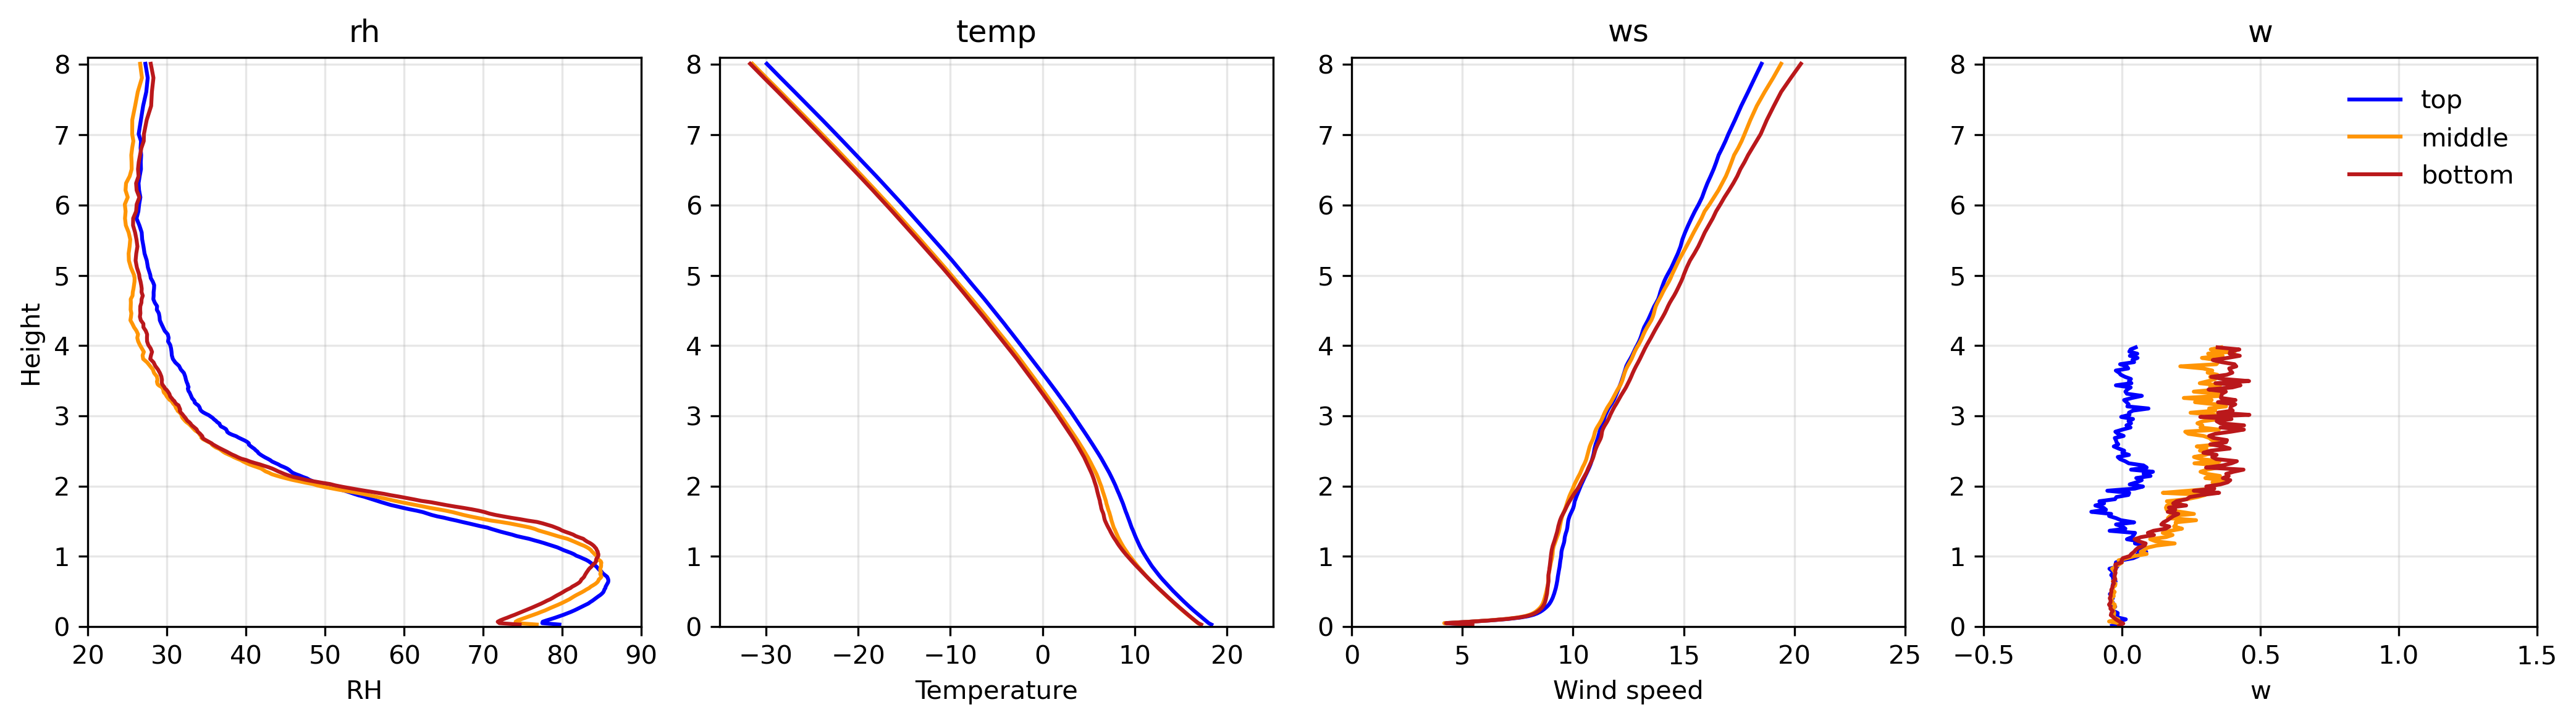

In [24]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ================= load =================
paths = {
    "top":    "/data/ggong/ARM_monthly/ENA/mete_profile/top",
    "middle": "/data/ggong/ARM_monthly/ENA/mete_profile/middle",
    "bottom": "/data/ggong/ARM_monthly/ENA/mete_profile/bottom",
}
cats = {k: (xr.open_dataset(f"{v}/ena_sonde_events_qc0_0to8p1km.nc"),
            xr.open_dataset(f"{v}/vv_profile.nc")) for k, v in paths.items()}
cat_colors = {"top": "b", "middle": "#ff9505", "bottom": "#ba181b"}

def _mean_profile(ds, var):
    h = ds.height.values
    v = ds[var].mean("time", skipna=True).values
    i = np.argsort(h)
    return h[i], v[i]

def _wind_speed_profile(ds):
    ws = np.sqrt(ds.u**2 + ds.v**2).mean("time", skipna=True).values
    h = ds.height.values
    i = np.argsort(h)
    return h[i], ws[i]

# ================= plot =================
fig, axes = plt.subplots(1, 4, figsize=(14, 4), dpi=300)
labels = [("rh","RH"), ("temp","Temperature"), ("ws","Wind speed"), ("w","w")]
xlims  = {"rh":(20,90), "temp":(-35,25), "ws":(0,25), "w":(-0.5,1.5)}

for ax, (var, xlabel) in zip(axes, labels):
    for k, (ds_me, ds_vv) in cats.items():
        if var == "ws": h, p = _wind_speed_profile(ds_me)
        elif var == "w": h, p = _mean_profile(ds_vv, "w")
        else: h, p = _mean_profile(ds_me, var)
        ax.plot(p, h, lw=1.5, color=cat_colors[k], label=k)
    ax.set(xlabel=xlabel, xlim=xlims[var], ylim=(0, 8.1), title=var)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Height")
fig.legend(*axes[0].get_legend_handles_labels(),
           loc="center left", bbox_to_anchor=(0.9, 0.8), frameon=False)

plt.tight_layout()
plt.show()

